<a href="https://colab.research.google.com/github/danielmarinho10-sudo/Inteligencia-Artificial-para-Seguranca-em-Bancos/blob/main/Projeto_IA_contra_fraudes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# "import X as Y" traz a biblioteca X e permite chamá-la pelo apelido Y
import pandas as pd            # pandas: tabelas de dados
import numpy as np             # numpy: números e aleatoriedade

# Do scikit-learn, importamos só as peças que vamos usar:
from sklearn.model_selection import train_test_split       # divide os dados em treino e teste
from sklearn.linear_model import LogisticRegression        # o primeiro modelo que vamos treinar
from sklearn.ensemble import RandomForestClassifier         # um segundo modelo, mais robusto
from sklearn.metrics import classification_report, confusion_matrix  # ferramentas de avaliação

import matplotlib.pyplot as plt   # para desenhar gráficos

# Fixamos uma "semente" (seed) de números aleatórios.
# Isso garante que, toda vez que você rodar o notebook, os dados simulados sejam os mesmos.
np.random.seed(42)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [29]:
# Carrega o arquivo CSV real que você subiu no Colab
dados = pd.read_csv("creditcard.csv")

# O dataset real chama a coluna de resposta de "Class" (0 = normal, 1 = fraude)
# Renomeamos para "fraude", assim todo o resto do notebook continua funcionando sem mudanças
dados = dados.rename(columns={"Class": "fraude"})

# A coluna "Time" é só o segundo em que a transação ocorreu desde o início da coleta,
# não ajuda o modelo a generalizar — então removemos
dados = dados.drop(columns=["Time"])

print("Conjunto de dados criado com", len(dados), "transações.")

Conjunto de dados criado com 284807 transações.


In [30]:
# .head() mostra as 5 primeiras linhas da tabela, só para dar uma olhada
dados.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,fraude
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [31]:
# .info() mostra quantas linhas existem, o tipo de cada coluna (número inteiro, decimal, etc.)
# e se há valores faltando
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

In [32]:
# .value_counts() conta quantas vezes cada valor aparece na coluna "fraude"
contagem = dados["fraude"].value_counts()
print(contagem)

# Calculamos a porcentagem de transações que são fraude
percentual_fraude = dados["fraude"].mean() * 100
print(f"\nPercentual de fraude no conjunto: {percentual_fraude:.2f}%")

fraude
0    284315
1       492
Name: count, dtype: int64

Percentual de fraude no conjunto: 0.17%


In [33]:
# X recebe todas as colunas, exceto "fraude" — são as "pistas" que o modelo vai usar
X = dados.drop(columns=["fraude"])

# y recebe só a coluna "fraude" — é a resposta que o modelo deve aprender a prever
y = dados["fraude"]

# train_test_split separa 80% dos dados para treino e 20% para teste
# stratify=y garante que a proporção de fraudes seja parecida nos dois grupos
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Linhas de treino:", len(X_treino))
print("Linhas de teste:", len(X_teste))

Linhas de treino: 227845
Linhas de teste: 56962


In [34]:
# Criamos o modelo, ainda "vazio", sem ter aprendido nada
modelo_lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

# .fit(X, y) é o comando que faz o modelo "estudar" os dados de treino
modelo_lr.fit(X_treino, y_treino)

print("Modelo de Regressão Logística treinado.")

Modelo de Regressão Logística treinado.


In [35]:
# .predict() usa o modelo já treinado para prever se cada transação de teste é fraude (1) ou não (0)
previsoes_lr = modelo_lr.predict(X_teste)

# classification_report calcula precision, recall e f1-score automaticamente
print(classification_report(y_teste, previsoes_lr, target_names=["normal", "fraude"]))

# confusion_matrix mostra: acertos e erros, separados por classe
print("Matriz de confusão (linhas = real, colunas = previsto):")
print(confusion_matrix(y_teste, previsoes_lr))

              precision    recall  f1-score   support

      normal       1.00      0.97      0.99     56864
      fraude       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

Matriz de confusão (linhas = real, colunas = previsto):
[[55421  1443]
 [    8    90]]


In [36]:
# n_estimators=200 significa que a "floresta" terá 200 árvores de decisão
modelo_rf = RandomForestClassifier(
    n_estimators=200, max_depth=6, class_weight="balanced_subsample", random_state=42
)

# Mesmo processo de antes: o modelo aprende com os dados de treino
modelo_rf.fit(X_treino, y_treino)

# Fazemos as previsões nos dados de teste
previsoes_rf = modelo_rf.predict(X_teste)

# E avaliamos do mesmo jeito
print(classification_report(y_teste, previsoes_rf, target_names=["normal", "fraude"]))
print("Matriz de confusão (linhas = real, colunas = previsto):")
print(confusion_matrix(y_teste, previsoes_rf))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     56864
      fraude       0.49      0.87      0.62        98

    accuracy                           1.00     56962
   macro avg       0.74      0.93      0.81     56962
weighted avg       1.00      1.00      1.00     56962

Matriz de confusão (linhas = real, colunas = previsto):
[[56774    90]
 [   13    85]]


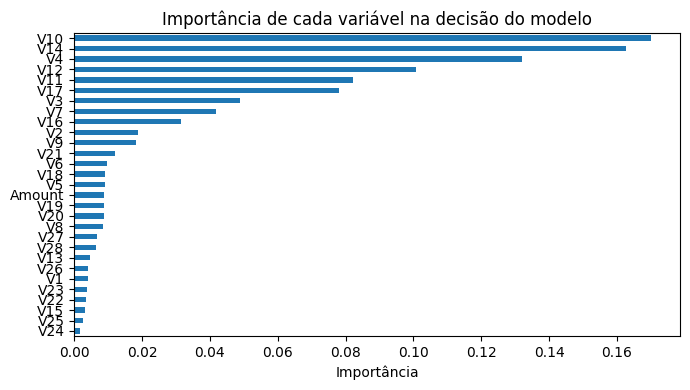

In [37]:
# .feature_importances_ traz um número para cada coluna de X, indicando sua importância
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)

# .sort_values ordena do mais importante para o menos importante
importancias = importancias.sort_values(ascending=True)

# Desenhamos um gráfico de barras horizontais
plt.figure(figsize=(7, 4))
importancias.plot(kind="barh")
plt.title("Importância de cada variável na decisão do modelo")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()